# K-Nearest Neighbors

Ky notebook trajnon dhe vlereson modelin K-Nearest Neighbors (KNN) per klasifikimin e cmimit te shtepive ne tri klasa: `Low`, `Medium`, `High`.

Per kete model perdoren dataset-et e klasifikimit te krijuara ne notebook-un `04_scaling_train_val_test_split.ipynb`:

- `train_dataset.csv`
- `val_dataset.csv`
- `test_dataset.csv`

Keto dataset-e jane te shkallezuara dhe kane target-in `price_class`. Shkallezimi eshte veçanerisht i rendesishem per KNN, sepse modeli bazohet ne distanca mes pikave.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

sns.set_theme(style="whitegrid")

## 1. Leximi i dataset-eve

Perdorim dataset-et e shkallezuara te klasifikimit, sepse KNN kerkon qe te gjitha veçorite te jene ne te njejten shkalle per te llogaritur distancat saktë.


In [3]:
data_dir = Path("../../data/processed")

train_df = pd.read_csv(data_dir / "train_dataset.csv")
val_df = pd.read_csv(data_dir / "val_dataset.csv")
test_df = pd.read_csv(data_dir / "test_dataset.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (12810, 53)
Validation shape: (4267, 53)
Test shape: (4279, 53)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,is_luxury_grade,is_high_view,is_premium,waterfront_grade,waterfront_sqft_living,view_grade,view_sqft_living,grade_lat_bin,grade_location_cluster,price_class
0,-0.400877,-1.474831,-1.014044,-0.225976,-0.905392,-0.073053,-0.297197,-0.637474,-0.552387,-0.736541,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,-0.565504,-0.413012,Low
1,-0.400877,0.205526,-0.386572,-0.196899,0.948224,-0.073053,-0.297197,-0.637474,-0.552387,-0.057074,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,-1.675403,-0.265497,Low
2,-0.400877,-1.474831,-0.310337,-0.180706,-0.905392,-0.073053,-0.297197,-0.637474,-0.552387,-0.901645,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,-0.565504,-1.150589,Low
3,-0.400877,0.541597,1.777328,-0.122849,-0.905392,-0.073053,-0.297197,-0.637474,0.332676,0.127080,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,0.544396,1.905088,High
4,-1.515537,-1.474831,-1.037501,-0.217270,-0.905392,-0.073053,-0.297197,0.886894,-0.552387,-1.142951,...,-0.267931,-0.185695,-0.317936,-0.071886,-0.069208,-0.290494,-0.271083,0.544396,-0.855558,Medium


## 2. Ndarja e veçorive dhe target-it


In [4]:
target_col = "price_class"
class_labels = ["Low", "Medium", "High"]

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_val = val_df.drop(columns=[target_col])
y_val = val_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print("Features:", X_train.shape[1])
print("Classes:", class_labels)
print("\nTrain class distribution:")
print(y_train.value_counts().reindex(class_labels, fill_value=0))

Features: 52
Classes: ['Low', 'Medium', 'High']

Train class distribution:
price_class
Low       4307
Medium    4279
High      4224
Name: count, dtype: int64


## 3. Model bazë

Fillimisht trajnojme nje KNN me nje vlere standarde te `k` (n_neighbors=5), qe te kemi nje baseline.


In [5]:
baseline_model = KNeighborsClassifier(n_neighbors=5)
baseline_model.fit(X_train, y_train)

baseline_val_pred = baseline_model.predict(X_val)

print("Baseline validation accuracy:", accuracy_score(y_val, baseline_val_pred))
print("Baseline validation F1 macro:", f1_score(y_val, baseline_val_pred, average="macro"))
print("\nClassification report:")
print(classification_report(
    y_val,
    baseline_val_pred,
    labels=class_labels,
    zero_division=0
))

Baseline validation accuracy: 0.7747832200609327
Baseline validation F1 macro: 0.7733034681719069

Classification report:
              precision    recall  f1-score   support

         Low       0.84      0.84      0.84      1442
      Medium       0.66      0.66      0.66      1390
        High       0.81      0.82      0.82      1435

    accuracy                           0.77      4267
   macro avg       0.77      0.77      0.77      4267
weighted avg       0.77      0.77      0.77      4267



## 4. Hyperparameter tuning

Testojme disa vlera per `n_neighbors`, si dhe per `weights` dhe `metric`. Si metrike perdorim f1_macro sepse kemi tri klasa dhe duam qe secila klase te kete rendesi te barabarte.


In [6]:
knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV f1_macro:", grid_search.best_score_)

def create_knn_model(params):
    return KNeighborsClassifier(**params)


Best params: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Best CV f1_macro: 0.8086882636793684


## 5. Vleresimi ne validation set me parametrat e zgjedhur

In [7]:
best_params = grid_search.best_params_

tuned_model = create_knn_model(best_params)
tuned_model.fit(X_train, y_train)

val_pred = tuned_model.predict(X_val)

print("Tuned validation accuracy:", accuracy_score(y_val, val_pred))
print("Tuned validation F1 macro:", f1_score(y_val, val_pred, average="macro"))
print("\nClassification report:")
print(classification_report(
    y_val,
    val_pred,
    labels=class_labels,
    zero_division=0
))

Tuned validation accuracy: 0.8132177173658308
Tuned validation F1 macro: 0.813072781013784

Classification report:
              precision    recall  f1-score   support

         Low       0.86      0.87      0.86      1442
      Medium       0.71      0.74      0.72      1390
        High       0.87      0.83      0.85      1435

    accuracy                           0.81      4267
   macro avg       0.81      0.81      0.81      4267
weighted avg       0.82      0.81      0.81      4267



## 6. Vleresimi final ne test set

Pasi parametrat zgjidhen duke perdorur train/validation, vleresimi final behet mbi test set. Per modelin final, bashkojme train dhe validation per trajnim.


In [8]:
X_train_final = pd.concat([X_train, X_val], ignore_index=True)
y_train_final = pd.concat([y_train, y_val], ignore_index=True)

final_model = create_knn_model(best_params)
final_model.fit(X_train_final, y_train_final)

test_pred = final_model.predict(X_test)

test_metrics = {
    "model": "KNN",
    "params": str(best_params),
    "accuracy": accuracy_score(y_test, test_pred),
    "precision_macro": precision_score(y_test, test_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, test_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, test_pred, average="macro", zero_division=0),
}

print("Test metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")

Test metrics:
  model: KNN
  params: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
  accuracy: 0.8142089273194671
  precision_macro: 0.8165835445095353
  recall_macro: 0.8138024345572377
  f1_macro: 0.8148869696275814


In [9]:
print(classification_report(
    y_test,
    test_pred,
    labels=class_labels,
    zero_division=0
))

              precision    recall  f1-score   support

         Low       0.87      0.85      0.86      1461
      Medium       0.71      0.75      0.73      1412
        High       0.87      0.84      0.85      1406

    accuracy                           0.81      4279
   macro avg       0.82      0.81      0.81      4279
weighted avg       0.82      0.81      0.82      4279



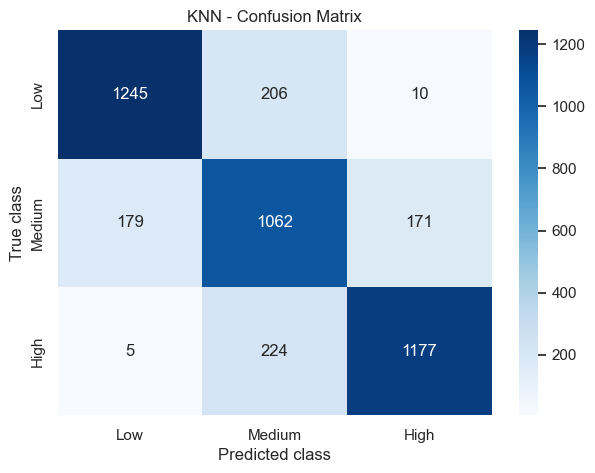

In [10]:
cm = confusion_matrix(y_test, test_pred, labels=class_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("KNN - Confusion Matrix")
plt.show()


## 7. Ndikimi i `k` ne performance

Vizualizojme se si ndryshon performanca (f1_macro) ne validation set per vlera te ndryshme te `n_neighbors`, duke mbajtur `weights` dhe `metric` te fiksuar nga kombinimi me i mire.


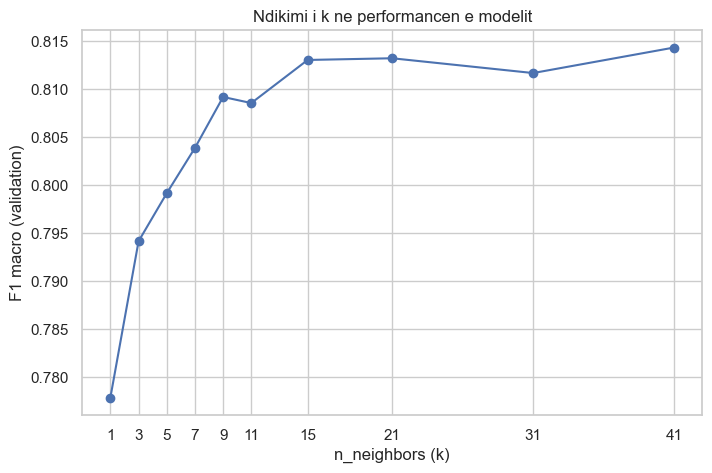

In [11]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 41]
f1_scores = []

fixed_params = {k: v for k, v in best_params.items() if k != "n_neighbors"}

for k in k_values:
    model = create_knn_model({**fixed_params, "n_neighbors": k})
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    f1_scores.append(f1_score(y_val, pred, average="macro"))

plt.figure(figsize=(8, 5))
plt.plot(k_values, f1_scores, marker="o")
plt.xlabel("n_neighbors (k)")
plt.ylabel("F1 macro (validation)")
plt.title("Ndikimi i k ne performancen e modelit")
plt.xticks(k_values)
plt.show()


## 8. Ruajtja e rezultateve

Rezultatet ruhen qe te perdoren me vone ne tabelen krahasuese finale me modelet tjera.


In [12]:
results_dir = data_dir / "model_results"
results_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame([test_metrics]).to_csv(results_dir / "knn_results.csv", index=False)

print("Results saved to:", results_dir)


Results saved to: ..\..\data\processed\model_results
